<a href="https://colab.research.google.com/github/Youssef-srf/Multiplication-de-Matrices-CPU-vs-GPU/blob/main/benchmark_cpu_gpu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Fri Jun 19 15:30:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

🔥 Préchauffage du GPU (Warmup)...
🚀 Début du Benchmarking avec analyse du goulot d'étranglement...

Calcul en cours pour une matrice 100 x 100...
   => CPU: 0.0002s | GPU Total: 0.0009s
      Détail GPU -> Transfert: 0.0004s + Calcul: 0.0005s
Calcul en cours pour une matrice 500 x 500...
   => CPU: 0.0061s | GPU Total: 0.0065s
      Détail GPU -> Transfert: 0.0026s + Calcul: 0.0038s
Calcul en cours pour une matrice 1000 x 1000...
   => CPU: 0.0367s | GPU Total: 0.0325s
      Détail GPU -> Transfert: 0.0042s + Calcul: 0.0283s
Calcul en cours pour une matrice 2000 x 2000...
   => CPU: 0.2862s | GPU Total: 0.1989s
      Détail GPU -> Transfert: 0.0161s + Calcul: 0.1828s
Calcul en cours pour une matrice 4000 x 4000...
   => CPU: 2.2356s | GPU Total: 0.7435s
      Détail GPU -> Transfert: 0.0585s + Calcul: 0.6851s
Calcul en cours pour une matrice 6000 x 6000...
   => CPU: 8.9379s | GPU Total: 1.9713s
      Détail GPU -> Transfert: 0.1297s + Calcul: 1.8416s
Calcul en cours pour une matrice 8

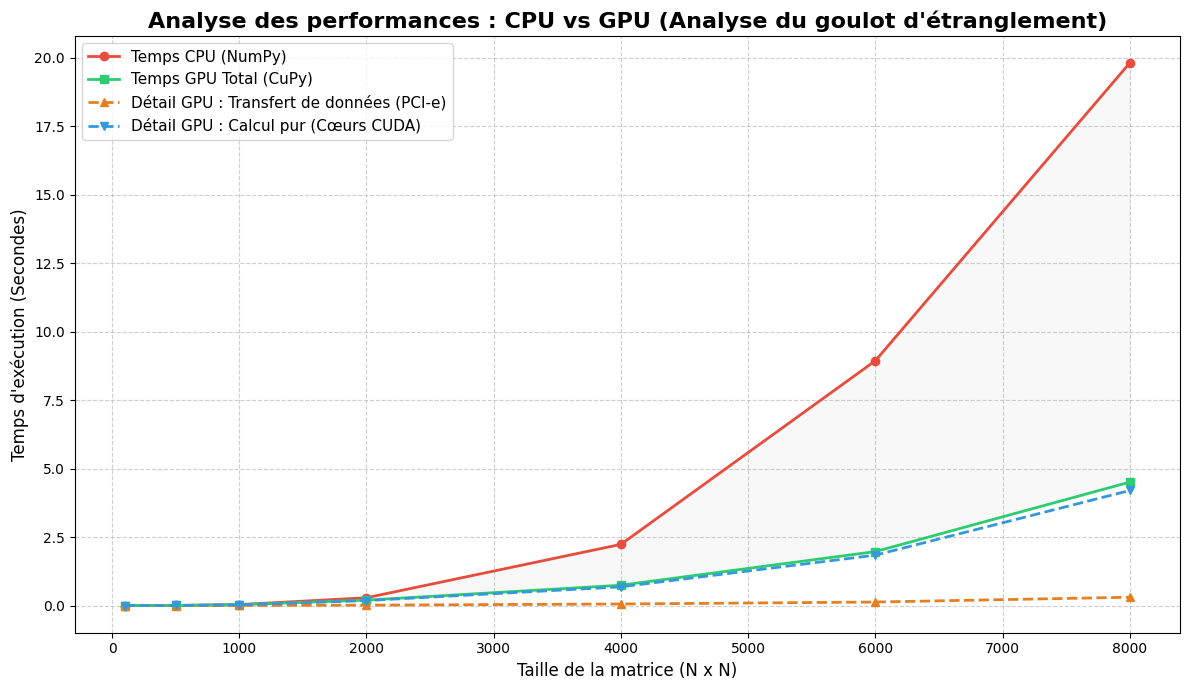

In [ ]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt

# Les différentes tailles de matrices que l'on va tester
tailles = [100, 500, 1000, 2000, 4000, 6000, 8000]

temps_cpu = []
temps_gpu_total = []
temps_gpu_transfert = []
temps_gpu_calcul = []

print("🔥 Préchauffage du GPU (Warmup)...")
# Initialisation de l'environnement CUDA
_ = cp.dot(cp.random.rand(100, 100), cp.random.rand(100, 100))
cp.cuda.Stream.null.synchronize()

print("🚀 Début du Benchmarking avec analyse du goulot d'étranglement...\n")

for n in tailles:
    print(f"Calcul en cours pour une matrice {n} x {n}...")

    # 1. Génération des données sur le CPU
    A_cpu = np.random.rand(n, n)
    B_cpu = np.random.rand(n, n)

    # 2. Chronométrage CPU (NumPy)
    debut_cpu = time.time()
    np.dot(A_cpu, B_cpu)
    t_cpu = time.time() - debut_cpu
    temps_cpu.append(t_cpu)

    # 3. Chronométrage du TRANSFERT (RAM -> VRAM)
    debut_transfert = time.time()
    A_gpu = cp.asarray(A_cpu)
    B_gpu = cp.asarray(B_cpu)
    cp.cuda.Stream.null.synchronize() # On attend que le transfert soit fini
    t_transfert = time.time() - debut_transfert
    temps_gpu_transfert.append(t_transfert)

    # 4. Chronométrage du CALCUL PUR sur le GPU
    debut_calcul = time.time()
    cp.dot(A_gpu, B_gpu)
    cp.cuda.Stream.null.synchronize() # On attend que le calcul soit fini
    t_calcul = time.time() - debut_calcul
    temps_gpu_calcul.append(t_calcul)

    # Temps total GPU
    t_gpu_total = t_transfert + t_calcul
    temps_gpu_total.append(t_gpu_total)

    # Affichage détaillé dans la console
    print(f"   => CPU: {t_cpu:.4f}s | GPU Total: {t_gpu_total:.4f}s")
    print(f"      Détail GPU -> Transfert: {t_transfert:.4f}s + Calcul: {t_calcul:.4f}s")

print("\n✅ Calculs terminés ! Génération du graphique...")

# --- Création du graphique pour la présentation ---
plt.figure(figsize=(12, 7))

# Courbe principale CPU (Rouge)
plt.plot(tailles, temps_cpu, marker='o', color='#e74c3c', linewidth=2, label='Temps CPU (NumPy)')

# Courbe principale GPU (Vert)
plt.plot(tailles, temps_gpu_total, marker='s', color='#2ecc71', linewidth=2, label='Temps GPU Total (CuPy)')

# Courbes de détail GPU (En pointillés)
plt.plot(tailles, temps_gpu_transfert, marker='^', color='#e67e22', linestyle='--', linewidth=2, label='Détail GPU : Transfert de données (PCI-e)')
plt.plot(tailles, temps_gpu_calcul, marker='v', color='#3498db', linestyle='--', linewidth=2, label='Détail GPU : Calcul pur (Cœurs CUDA)')

# Esthétique du graphique
plt.title("Analyse des performances : CPU vs GPU (Analyse du goulot d'étranglement)", fontsize=16, fontweight='bold')
plt.xlabel("Taille de la matrice (N x N)", fontsize=12)
plt.ylabel("Temps d'exécution (Secondes)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.fill_between(tailles, temps_cpu, temps_gpu_total, color='#bdc3c7', alpha=0.1)

# Affichage
plt.tight_layout()
plt.show()

🔥 Préchauffage du GPU...
🚀 Lancement du Benchmark de Haute Performance...

Calcul matrice 100x100...
Calcul matrice 500x500...
Calcul matrice 1000x1000...
Calcul matrice 2000x2000...
Calcul matrice 4000x4000...
Calcul matrice 6000x6000...
Calcul matrice 8000x8000...
Calcul matrice 10000x10000...

✅ Calculs terminés ! Création du tableau de bord...


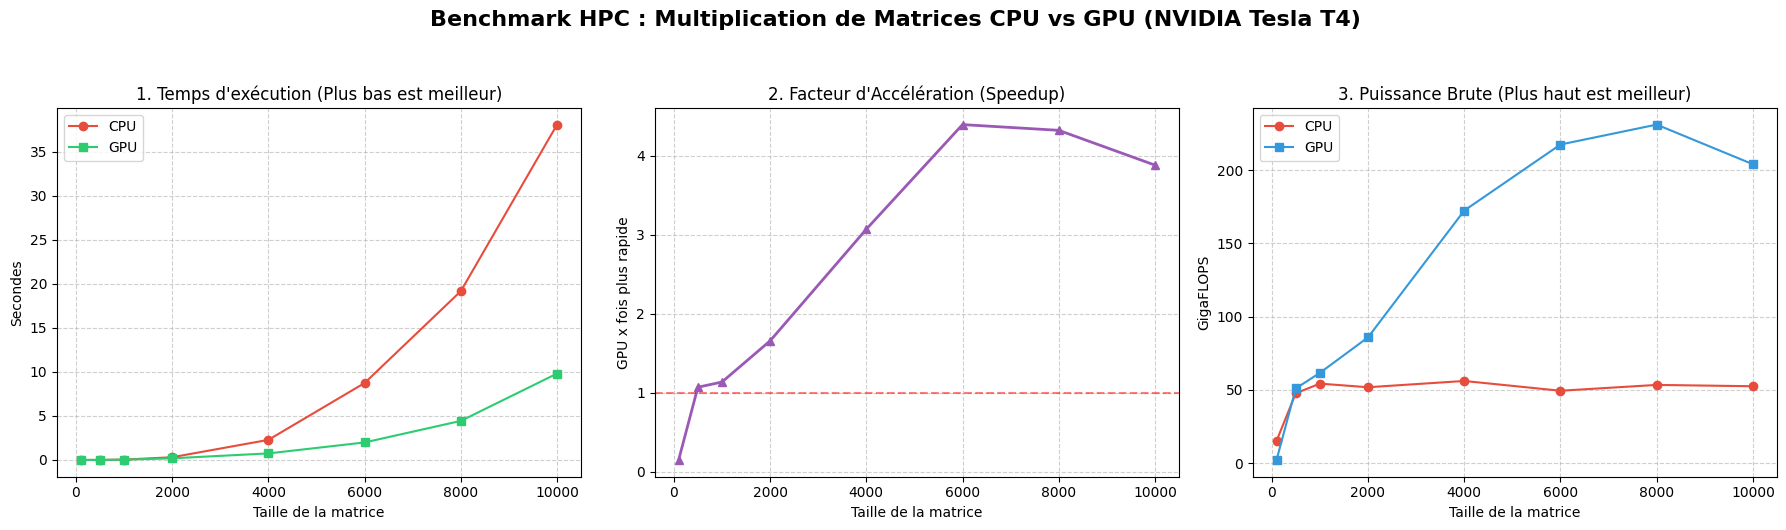

In [ ]:
import numpy as np
import cupy as cp
import time
import matplotlib.pyplot as plt

# Tailles des matrices
tailles = [100, 500, 1000, 2000, 4000, 6000, 8000, 10000]

temps_cpu, temps_gpu = [], []
speedup = []
gflops_cpu, gflops_gpu = [], []

print("🔥 Préchauffage du GPU...")
_ = cp.dot(cp.random.rand(100, 100), cp.random.rand(100, 100))
cp.cuda.Stream.null.synchronize()

print("🚀 Lancement du Benchmark de Haute Performance...\n")

for n in tailles:
    print(f"Calcul matrice {n}x{n}...")

    # Nombre total d'opérations flottantes pour une multiplication matricielle (2 * N^3)
    operations = 2.0 * (n ** 3)

    A_cpu = np.random.rand(n, n)
    B_cpu = np.random.rand(n, n)

    # --- CPU ---
    debut_cpu = time.time()
    np.dot(A_cpu, B_cpu)
    t_cpu = time.time() - debut_cpu
    temps_cpu.append(t_cpu)
    gflops_cpu.append((operations / t_cpu) / 1e9) # Conversion en GigaFLOPS

    # --- GPU ---
    debut_gpu = time.time()
    A_gpu = cp.asarray(A_cpu)
    B_gpu = cp.asarray(B_cpu)
    cp.dot(A_gpu, B_gpu)
    cp.cuda.Stream.null.synchronize()
    t_gpu = time.time() - debut_gpu
    temps_gpu.append(t_gpu)
    gflops_gpu.append((operations / t_gpu) / 1e9)

    # --- Speedup ---
    speedup.append(t_cpu / t_gpu)

print("\n✅ Calculs terminés ! Création du tableau de bord...")

# --- AFFICHAGE DU DASHBOARD (1 Ligne, 3 Colonnes) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Benchmark HPC : Multiplication de Matrices CPU vs GPU (NVIDIA Tesla T4)", fontsize=16, fontweight='bold', y=1.05)

# Graphique 1 : Temps d'exécution
axes[0].plot(tailles, temps_cpu, marker='o', color='#e74c3c', label='CPU')
axes[0].plot(tailles, temps_gpu, marker='s', color='#2ecc71', label='GPU')
axes[0].set_title("1. Temps d'exécution (Plus bas est meilleur)")
axes[0].set_xlabel("Taille de la matrice")
axes[0].set_ylabel("Secondes")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# Graphique 2 : Facteur d'accélération (Speedup)
axes[1].plot(tailles, speedup, marker='^', color='#9b59b6', linewidth=2)
axes[1].axhline(y=1, color='r', linestyle='--', alpha=0.5) # Ligne de base CPU
axes[1].set_title("2. Facteur d'Accélération (Speedup)")
axes[1].set_xlabel("Taille de la matrice")
axes[1].set_ylabel("GPU x fois plus rapide")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Graphique 3 : Puissance brute (GFLOPS)
axes[2].plot(tailles, gflops_cpu, marker='o', color='#e74c3c', label='CPU')
axes[2].plot(tailles, gflops_gpu, marker='s', color='#3498db', label='GPU')
axes[2].set_title("3. Puissance Brute (Plus haut est meilleur)")
axes[2].set_xlabel("Taille de la matrice")
axes[2].set_ylabel("GigaFLOPS")
axes[2].legend()
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()